In [1]:
#Preamble
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pydicom as dcm
import math
import os

### Plotting dose and LET as function of depth
Done using water phantom
LET vektet dose was computed using the RayStation script that computes an evaluation dose using a model of your selection. I used the LET-vektet option for this example. 
This data was exported along with physical dose and LET using the LET export script.

In [15]:
path = r"C:\Users\bhaan\Downloads\Unrestricted beam plan - LET and RTStruct wo range shifter\roi_let_dose_coords_WaterPhantom.csv"
data_waterphantom = pd.read_csv(path)
print(data_waterphantom.head())

      x_mm     y_mm    z_mm  LET_keV_per_um   Dose_Gy  LET_vektet_dose
0 -14.6404 -135.029 -236.15        2.743656  0.056273         0.064765
1 -14.3404 -135.029 -236.15        1.869915  0.058764         0.064808
2 -14.0404 -135.029 -236.15        2.398632  0.065736         0.074408
3 -13.7404 -135.029 -236.15        2.644752  0.071730         0.082164
4 -13.4404 -135.029 -236.15        2.177603  0.072586         0.081279


In [16]:
#Find middle x and y
x_mid = np.unique(data_waterphantom['x_mm'])[round(len(np.unique(data_waterphantom['x_mm']))/2)]
z_mid = np.unique(data_waterphantom['z_mm'])[round(len(np.unique(data_waterphantom['z_mm']))/2)]

#Extract data with this x and y
lineprofile = data_waterphantom[(data_waterphantom['x_mm']==x_mid) & (data_waterphantom['z_mm']==z_mid)]
print(lineprofile)


          x_mm     y_mm    z_mm  LET_keV_per_um   Dose_Gy  LET_vektet_dose
667898 -0.2404 -135.029 -225.05        2.741313  0.000041         0.000047
667993 -0.2404 -134.729 -225.05        2.714425  0.000016         0.000019
668088 -0.2404 -134.429 -225.05        0.000000  0.000000         0.000000
668183 -0.2404 -134.129 -225.05        2.377136  0.000006         0.000007
668278 -0.2404 -133.829 -225.05        2.904258  0.000067         0.000078
...        ...      ...     ...             ...       ...              ...
685473 -0.2404  -79.529 -225.05        1.132318  0.470687         0.500000
685568 -0.2404  -79.229 -225.05        1.061322  0.465998         0.493200
685663 -0.2404  -78.929 -225.05        1.059537  0.466506         0.493691
685758 -0.2404  -78.629 -225.05        1.059925  0.464723         0.491815
685853 -0.2404  -78.329 -225.05        1.039072  0.459429         0.485684

[190 rows x 6 columns]


In [18]:
#Process data
ydata = np.array(abs(lineprofile['y_mm']))
letdata = np.array(lineprofile['LET_keV_per_um'])
dosedata = np.array(lineprofile['Dose_Gy'])

#Want depth to start at zero
ydata = ydata - min(ydata)
#Sort depth data in ascending order
sort = np.argsort(ydata)
#Apply sorting to all variables
ydata = ydata[sort]
letdata = letdata[sort]
dosedata = dosedata[sort]

#Truncate data once dose drops to zero
stopindex = np.where(dosedata==0)[0][0]
ydata = ydata[0:stopindex]
letdata = letdata[0:stopindex]
dosedata = dosedata[0:stopindex]

# #Want dose and let normalised to maximum
# letdata = letdata/max(letdata)
# dosedata = dosedata/max(dosedata)


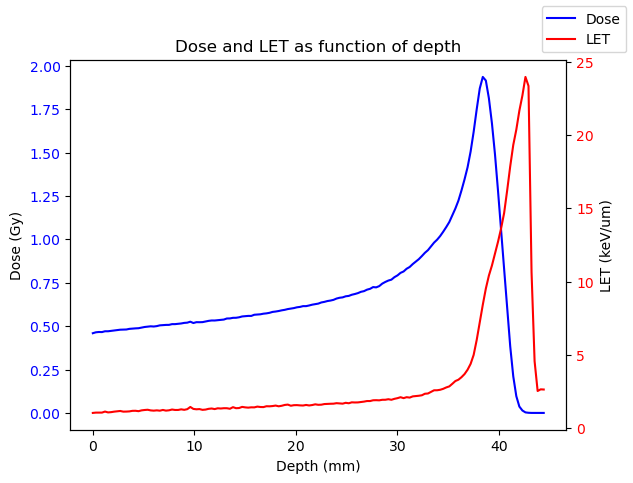

In [19]:
#Plot lineprofile as function of depth
fig, ax1 = plt.subplots()

ax1.plot(ydata, dosedata, label='Dose', color='b')
ax1.set_xlabel('Depth (mm)')
ax1.set_ylabel('Dose (Gy)')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
ax2.plot(ydata, letdata, label='LET', color='r')
ax2.set_ylabel('LET (keV/um)')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('Dose and LET as function of depth')

handles = []
labels = []
for ax in fig.axes:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

fig.legend(handles, labels)

Note: the jiggle wiggle of the LET after the maximum is probably some Monte Carlo noise

### Generate LET map of the cell layer

Done for the ROI 'Cell Layer'

In [32]:
path = r"C:\Users\bhaan\Downloads\Unrestricted beam plan - LET and RTStruct wo range shifter\roi_let_dose_coords_CellLayer.csv"
data_cells = pd.read_csv(path)

In [33]:
#Due to the fineness of the dose grid the cell layer also has multiple depth values
#I'll map the first one
slice = data_cells[data_cells['y_mm']==data_cells['y_mm'].unique()[0]]

#Set up image array
x_vals = slice['x_mm'].unique()
z_vals = slice['z_mm'].unique()
imarray = np.zeros([int(len(z_vals)), int(len(x_vals))])

#Populate image array with LET values
for i in slice.index.tolist():
    datapoint = slice.loc[i]
    x = datapoint.x_mm
    z = datapoint.z_mm
    let = datapoint.LET_keV_per_um

    x_index = np.where(x_vals == x)
    z_index = np.where(z_vals == z)

    imarray[z_index, x_index] = let

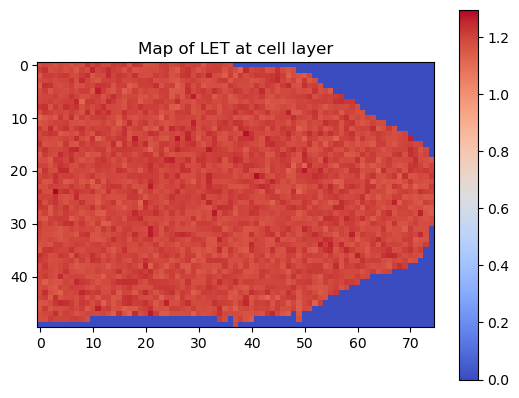

In [34]:
#Regular plot
plt.imshow(imarray,cmap='coolwarm')
plt.title('Map of LET at cell layer')
plt.colorbar()

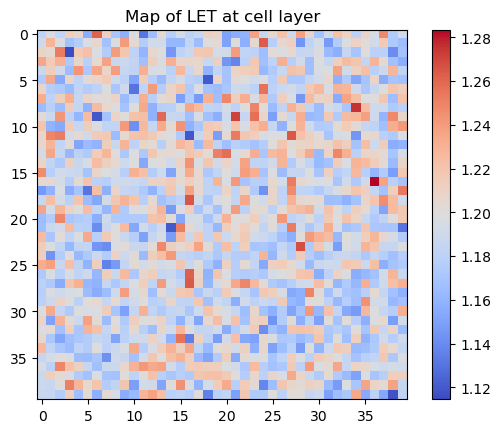

In [35]:
#Crop images to be only inside the cell flask --> highlight differences
imarray_crop = imarray[5:45, 5:45]

#Regular plot
plt.imshow(imarray_crop,cmap='coolwarm')
plt.title('Map of LET at cell layer')
plt.colorbar()

Note: we see that it is relatively homogenous (1.12-1.28). Some fluctuation also due to Monte Carlo noise.

### Obtain dose and LET in POI

POI = dose point at cells, useful for modelling

In [36]:
sinfo = dcm.dcmread(r"C:\Users\bhaan\Downloads\Unrestricted beam plan - LET and RTStruct wo range shifter\RS1.2.752.243.1.1.20250930174435778.1300.32864.dcm")

#Find the ROI that represents the point
for i in range(len(sinfo.ROIContourSequence)):
    if sinfo.ROIContourSequence[i].ContourSequence[0].ContourGeometricType == 'POINT':
        #This is the point, store the coordinates
        coords = np.array(sinfo.ROIContourSequence[i].ContourSequence[0].ContourData)

print(coords)

[  44.76693  -82.14333 -261.     ]


In [ ]:
#I override the location of coords for now bc the dose point is not in the water phantom area
coords = np.array([-6.540400,-107.429000,-236.750000])

In [ ]:
#Find point in LET data
#I could also look for it in cell layer if I don't have the water phantom ROI
#Or I could get this data from averaging (a region of) the cell layer ROI
pointdata = data_waterphantom[(data_waterphantom['x_mm']==coords[0]) & (data_waterphantom['y_mm']==coords[1]) & (data_waterphantom['z_mm']==coords[2])]
print('LET in POI: ' + str(pointdata['LET_keV_per_um'].values[0]) + ' keV/um')
print('Dose in POI: ' + str(pointdata['Dose_GyRBE'].values[0]) + ' Gy')

LET in POI: 1.553699 keV/um
Dose in POI: 0.562326 Gy


### Comparing the dose in water phantom to the curves exported from RayPhysics


In [19]:
path = r"C:\Users\bhaan\Downloads\MeasuredBP_69MeV.xlsx"
data = pd.read_excel(path)

RSdepth_m = np.array(data['Depth'])
RSdose_m = np.array(data['Dose'])

#Want depth to start at zero
RSdepth_m = RSdepth_m #- min(RSdepth)
#Sort depth data in ascending order
sort = np.argsort(RSdepth_m)
#Apply sorting to all variables
RSdepth_m = RSdepth_m[sort]
RSdose_m = RSdose_m[sort]

#Want dose and let normalised to maximum
RSdose_m = RSdose_m/max(RSdose_m)

path = r"C:\Users\bhaan\Downloads\CalculatedBP_69MeV.xlsx"
data = pd.read_excel(path)

RSdepth_c = np.array(data['Depth'])
RSdose_c = np.array(data['Dose'])

#Want depth to start at zero
RSdepth_c = RSdepth_c #- min(RSdepth)
#Sort depth data in ascending order
sort = np.argsort(RSdepth_c)
#Apply sorting to all variables
RSdepth_c = RSdepth_c[sort]
RSdose_c = RSdose_c[sort]

#Want dose and let normalised to maximum
RSdose_c = RSdose_c/max(RSdose_c)

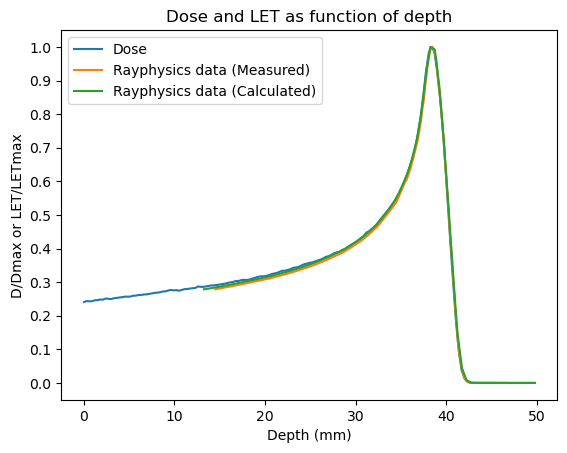

In [21]:
#Plot together with other data to compare
plt.plot(ydata, dosedata/max(dosedata), label='Dose')
plt.plot(RSdepth_m, RSdose_m, label='Rayphysics data (Measured)')
plt.plot(RSdepth_c, RSdose_c, label='Rayphysics data (Calculated)')
plt.title('Dose and LET as function of depth')
plt.xlabel('Depth (mm)')
plt.ylabel('D/Dmax or LET/LETmax')
plt.yticks(np.arange(0, 1.1, 0.1))
plt.legend()

### Adding LET-vektet dose

LET vektet dose was computed using the RayStation script that computes an evaluation dose using a model of your selection. I used the LET-vektet option for this example. 
This data was exported along with physical dose and LET using the LET export script.

In [11]:
path = r"C:\Users\bhaan\Downloads\Unrestricted beam plan - LET and RTStruct wo range shifter\roi_let_dose_coords_WaterPhantom.csv"
data = pd.read_csv(path)
print(data.head())

      x_mm     y_mm    z_mm  LET_keV_per_um   Dose_Gy  LET_vektet_dose
0 -14.6404 -135.029 -236.15        2.743656  0.056273         0.064765
1 -14.3404 -135.029 -236.15        1.869915  0.058764         0.064808
2 -14.0404 -135.029 -236.15        2.398632  0.065736         0.074408
3 -13.7404 -135.029 -236.15        2.644752  0.071730         0.082164
4 -13.4404 -135.029 -236.15        2.177603  0.072586         0.081279


In [13]:
#Find middle x and y
x_mid = np.unique(data['x_mm'])[round(len(np.unique(data['x_mm']))/2)]
z_mid = np.unique(data['z_mm'])[round(len(np.unique(data['z_mm']))/2)]

#Extract data with this x and y
lineprofile = data[(data['x_mm']==x_mid) & (data['z_mm']==z_mid)]

#Process data
ydata = np.array(abs(lineprofile['y_mm']))
letdata = np.array(lineprofile['LET_keV_per_um'])
dosedata = np.array(lineprofile['Dose_Gy'])
letdosedata = np.array(lineprofile['LET_vektet_dose'])

#Want depth to start at zero
ydata = ydata - min(ydata)
#Sort depth data in ascending order
sort = np.argsort(ydata)
#Apply sorting to all variables
ydata = ydata[sort]
letdata = letdata[sort]
dosedata = dosedata[sort]
letdosedata = letdosedata[sort]

# #Truncate data once dose drops to zero
# stopindex = np.where(dosedata==0)[0][0]
# ydata = ydata[0:stopindex]
# letdata = letdata[0:stopindex]
# dosedata = dosedata[0:stopindex]
# letdosedata = letdosedata[0:stopindex]

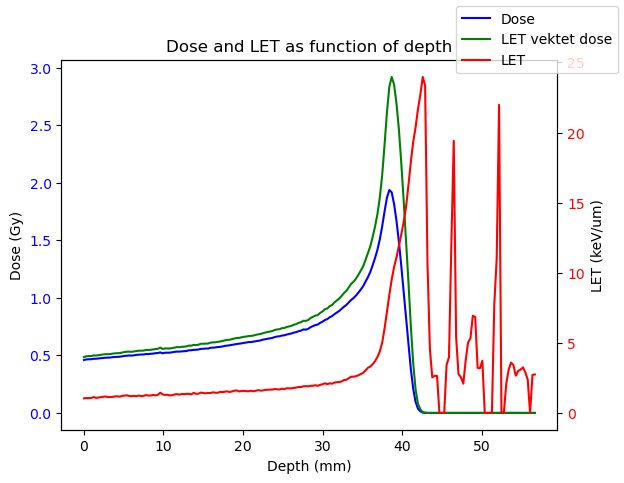

In [14]:
#Plot lineprofile as function of depth
fig, ax1 = plt.subplots()

ax1.plot(ydata, dosedata, label='Dose', color='b')
ax1.plot(ydata, letdosedata, label='LET vektet dose', color='g')
ax1.set_xlabel('Depth (mm)')
ax1.set_ylabel('Dose (Gy)')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
ax2.plot(ydata, letdata, label='LET', color='r')
ax2.set_ylabel('LET (keV/um)')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('Dose and LET as function of depth')

handles = []
labels = []
for ax in fig.axes:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

fig.legend(handles, labels)